<a href="https://colab.research.google.com/github/RomanPikhotskiy/dsp-seminars/blob/pikhotskiy_r/seminars/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


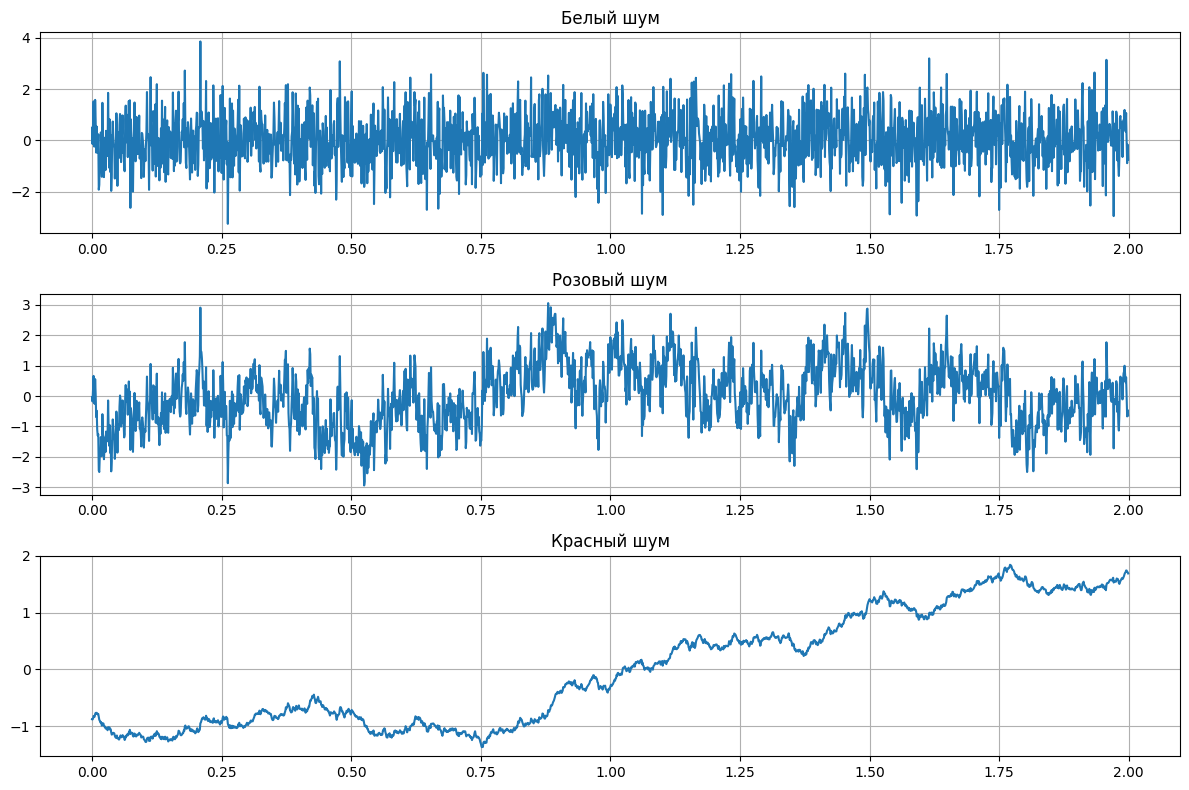

Белый шум: среднее = 0.0450841465357407 дисперсия = 0.9765758247496166
Розовый шум: среднее = 1.4210854715202004e-17 дисперсия = 1.0
Красный шум: среднее = 0.0 дисперсия = 0.9999999999999998


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

np.random.seed(42)

fs = 1000
duration = 2
N = fs * duration
t = np.arange(N) / fs

white = np.random.normal(0, 1, N)

X = np.fft.rfft(white)
f = np.fft.rfftfreq(N, d=1/fs)
scale = np.ones_like(f)
scale[1:] = 1 / np.sqrt(f[1:])
pink = np.fft.irfft(X * scale, n=N)
pink = (pink - np.mean(pink)) / np.std(pink)

red = np.cumsum(white)
red = (red - np.mean(red)) / np.std(red)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, white)
plt.title('Белый шум')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, pink)
plt.title('Розовый шум')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, red)
plt.title('Красный шум')
plt.grid()

plt.tight_layout()
plt.show()

print("Белый шум: среднее =", np.mean(white), "дисперсия =", np.var(white))
print("Розовый шум: среднее =", np.mean(pink), "дисперсия =", np.var(pink))
print("Красный шум: среднее =", np.mean(red), "дисперсия =", np.var(red))

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Белый шум визуально выглядит как быстро меняющийся случайный сигнал без заметной плавности.  
Розовый шум выглядит более сглаженным, так как в нём сильнее выражены низкие частоты.  
Красный шум ещё более плавный и медленно меняется во времени, потому что получается накоплением случайных изменений.

Средние значения всех сигналов должны быть близки к нулю, а дисперсии — близки к единице.  
Однако они могут немного отличаться от теоретических значений, потому что рассматривается конечная реализация случайного процесса, а не бесконечный сигнал.  
Кроме того, розовый и красный шум в этом задании дополнительно нормализуются, поэтому их среднее и дисперсия после обработки становятся близкими к 0 и 1 соответственно.

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


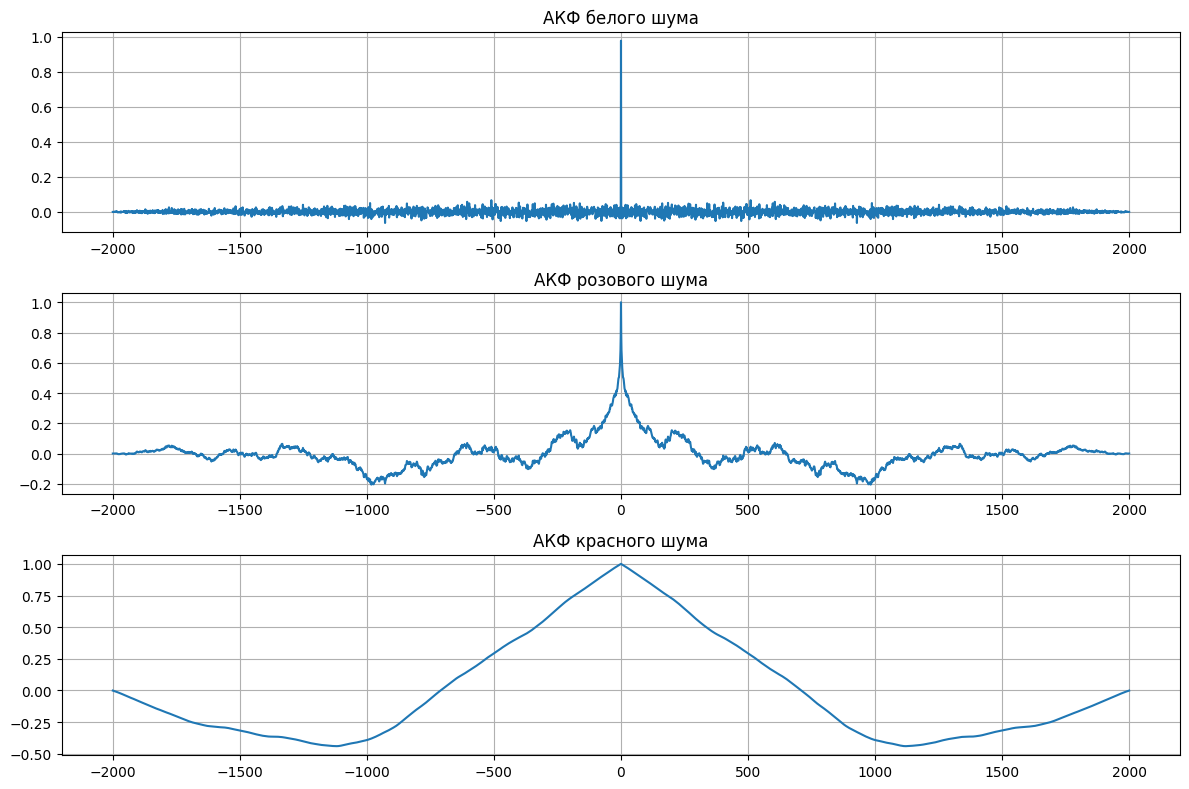

In [11]:
def autocorr(x):
    x = x - np.mean(x)
    return np.correlate(x, x, mode='full') / len(x)

acf_white = autocorr(white)
acf_pink = autocorr(pink)
acf_red = autocorr(red)

lags = np.arange(-len(white) + 1, len(white))

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(lags, acf_white)
plt.title('АКФ белого шума')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(lags, acf_pink)
plt.title('АКФ розового шума')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(lags, acf_red)
plt.title('АКФ красного шума')
plt.grid()

plt.tight_layout()
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


У белого шума автокорреляционная функция имеет выраженный пик только при нулевом сдвиге, а при остальных сдвигах значения близки к нулю.  
Это означает, что значения белого шума практически не связаны друг с другом.

У розового шума автокорреляция убывает медленнее, так как в нём сильнее выражены низкие частоты и соседние значения уже более зависимы.  

У красного шума автокорреляция спадает ещё медленнее, потому что такой шум получается накоплением белого шума и обладает сильной временной зависимостью.

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


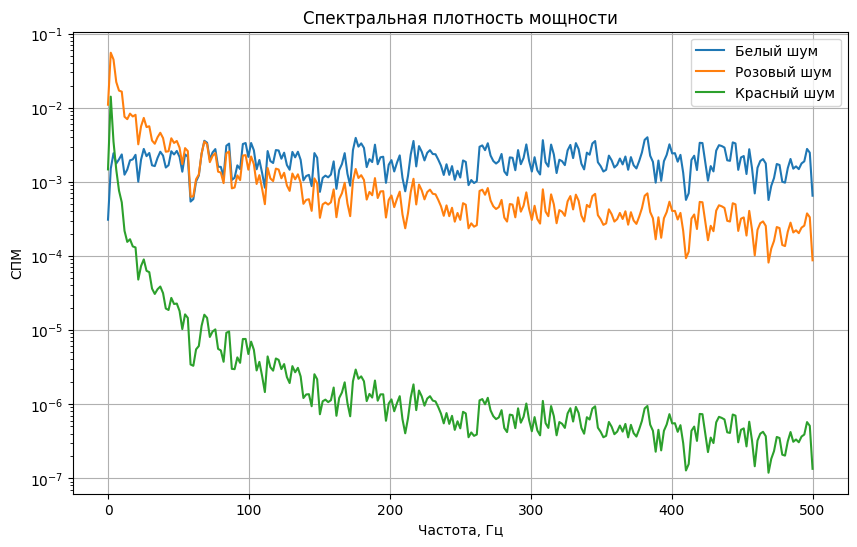

In [12]:
fs = 1000

f_white, Pxx_white = signal.welch(white, fs=fs, nperseg=512)
f_pink, Pxx_pink = signal.welch(pink, fs=fs, nperseg=512)
f_red, Pxx_red = signal.welch(red, fs=fs, nperseg=512)

plt.figure(figsize=(10, 6))
plt.semilogy(f_white, Pxx_white, label='Белый шум')
plt.semilogy(f_pink, Pxx_pink, label='Розовый шум')
plt.semilogy(f_red, Pxx_red, label='Красный шум')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.title('Спектральная плотность мощности')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


У белого шума спектральная плотность мощности почти постоянна по всем частотам, поэтому его спектр близок к равномерному.  

У розового шума спектральная плотность убывает с ростом частоты, поэтому низкие частоты выражены сильнее высоких.  

У красного шума спад по частоте ещё сильнее, поэтому основная энергия сосредоточена в области самых низких частот.

Таким образом, по виду спектра видно, что белый шум содержит все частоты примерно одинаково, розовый шум смещён в сторону низких частот, а красный шум ещё сильнее концентрируется на низких частотах.

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


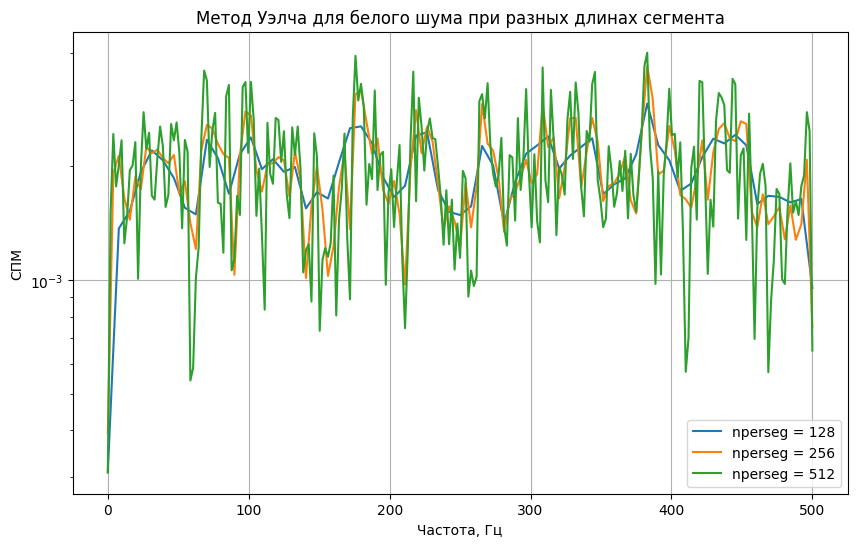

In [13]:
segment_lengths = [128, 256, 512]

plt.figure(figsize=(10, 6))

for nperseg in segment_lengths:
    f, Pxx = signal.welch(white, fs=fs, nperseg=nperseg)
    plt.semilogy(f, Pxx, label=f'nperseg = {nperseg}')

plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.title('Метод Уэлча для белого шума при разных длинах сегмента')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


При увеличении длины сегмента частотное разрешение улучшается, поэтому спектр становится более детализированным.  
Однако при этом оценка становится менее сглаженной и более шумной.

При меньшей длине сегмента спектр получается более усреднённым и гладким, но хуже различаются близкие частоты.

Таким образом, длина сегмента влияет на компромисс между сглаживанием спектра и частотным разрешением.

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

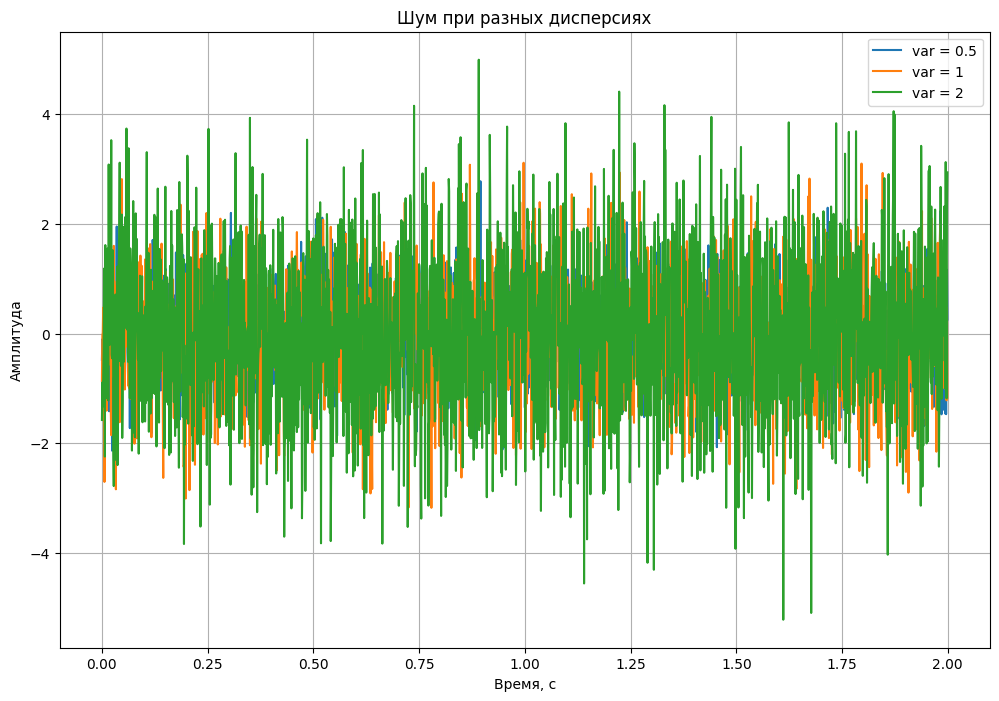

var = 0.5: среднее = 0.002, дисперсия = 0.488
var = 1: среднее = -0.026, дисперсия = 0.985
var = 2: среднее = 0.051, дисперсия = 1.998


In [14]:
variances = [0.5, 1, 2]

plt.figure(figsize=(12, 8))

for var in variances:
    noise = np.sqrt(var) * np.random.randn(N)
    plt.plot(t, noise, label=f'var = {var}')

plt.legend()
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Шум при разных дисперсиях')
plt.grid()
plt.show()

for var in variances:
    noise = np.sqrt(var) * np.random.randn(N)
    print(f'var = {var}: среднее = {np.mean(noise):.3f}, дисперсия = {np.var(noise):.3f}')

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


При увеличении дисперсии увеличивается разброс значений сигнала относительно среднего.  
Шум становится более "сильным" по амплитуде, значения отклоняются дальше от нуля.

При этом форма шума остаётся случайной и не меняется по структуре — изменяется только масштаб колебаний.

Вычисленные значения дисперсии близки к заданным, но могут немного отличаться из-за случайного характера сигнала и конечной длины выборки.

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


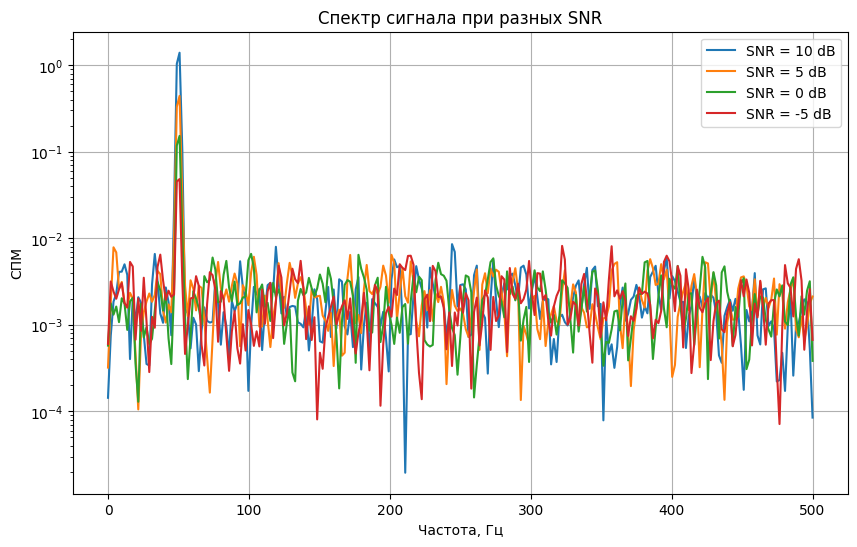

In [15]:
t = np.arange(0, 1, 1 / fs)
signal_clean = np.sin(2 * np.pi * 50 * t)

snr_levels = [10, 5, 0, -5]

plt.figure(figsize=(10, 6))

for snr in snr_levels:
    noise = np.random.randn(len(t))
    A = 10 ** (snr / 20)
    noisy = A * signal_clean + noise

    f, Pxx = signal.welch(noisy, fs=fs, nperseg=512)
    plt.semilogy(f, Pxx, label=f'SNR = {snr} dB')

plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.title('Спектр сигнала при разных SNR')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


При уменьшении отношения сигнал/шум спектральный пик полезного сигнала становится менее выраженным.  
При высоком SNR пик на частоте сигнала хорошо виден и легко различим.

При уменьшении SNR шум начинает доминировать, и пик постепенно "теряется" на фоне шума.  
При низком SNR сигнал может быть практически неразличим в спектре.

Таким образом, чем ниже SNR, тем сложнее обнаружить полезный сигнал по спектру.

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


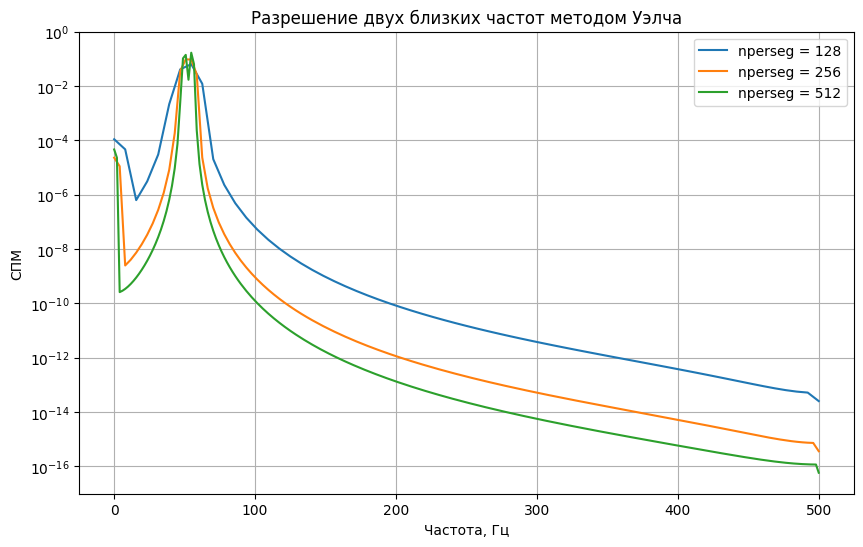

In [16]:
t = np.arange(0, 1, 1 / fs)
x = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 55 * t)

segment_lengths = [128, 256, 512]

plt.figure(figsize=(10, 6))

for nperseg in segment_lengths:
    f, Pxx = signal.welch(x, fs=fs, nperseg=nperseg)
    plt.semilogy(f, Pxx, label=f'nperseg = {nperseg}')

plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.title('Разрешение двух близких частот методом Уэлча')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


Чем больше длина сегмента, тем лучше частотное разрешение и тем легче различить две близкие частоты.  

При маленькой длине сегмента спектральные пики получаются более широкими и могут сливаться в один общий максимум.  
При увеличении длины сегмента пики становятся уже, и две частоты начинают разделяться лучше.

Таким образом, увеличение длины сегмента улучшает способность различать близкие по частоте компоненты сигнала.